# E-Commerce Sales Analytics

## Project Overview

This project analyzes transactional data from an online retail business to understand sales performance, customer behavior, product performance, returns, and geographic trends.

The objective is to transform raw transactional data into actionable business insights using Python and data analytics techniques.

### Key Areas of Analysis
- Sales and revenue performance
- Product performance
- Customer behavior
- RFM customer segmentation
- Geographic performance
- Return and cancellation analysis
- Time-based sales patterns
- Business insights and recommendations

In [1]:
print("E-commerce Sales Analytics Project Started!")

E-commerce Sales Analytics Project Started!


## 1. Import Libraries

In [2]:
import sys
print(sys.executable)

c:\Users\shaws\Desktop\Ecommerce-Sales-Analytics\.venv\Scripts\python.exe


In [3]:
import sys
print(sys.executable)

c:\Users\shaws\Desktop\Ecommerce-Sales-Analytics\.venv\Scripts\python.exe


## 2. Load Dataset

In [4]:
import pandas as pd

print("Pandas version:", pd.__version__)

Pandas version: 3.0.5


In [5]:
import pandas as pd

file_path = "online_retail_II.xlsx"

df = pd.read_excel(file_path)

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## 3. Data Understanding

In [6]:
df.shape

(525461, 8)

In [7]:
df.columns


Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='str')

In [8]:
df.dtypes


Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
Price                 float64
Customer ID           float64
Country                   str
dtype: object

In [9]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(6865)

In [11]:
(df["Quantity"] < 0).sum()

np.int64(12326)

In [12]:
(df["Price"] <= 0).sum()


np.int64(3690)

In [13]:
df["InvoiceDate"].min(), df["InvoiceDate"].max()

(Timestamp('2009-12-01 07:45:00'), Timestamp('2010-12-09 20:01:00'))

In [14]:
df["Customer ID"].nunique()

4383

In [15]:
print("Unique invoices:", df["Invoice"].nunique())
print("Unique products:", df["StockCode"].nunique())
print("Unique countries:", df["Country"].nunique())
print("Unique descriptions:", df["Description"].nunique())

Unique invoices: 28816
Unique products: 4632
Unique countries: 40
Unique descriptions: 4681


In [16]:
print("Negative quantity invoices:", df.loc[df["Quantity"] < 0, "Invoice"].nunique())
print("Negative quantity rows:", (df["Quantity"] < 0).sum())
print("Zero/negative price rows:", (df["Price"] <= 0).sum())
print("Zero price rows:", (df["Price"] == 0).sum())

Negative quantity invoices: 6712
Negative quantity rows: 12326
Zero/negative price rows: 3690
Zero price rows: 3687


In [17]:
negative_price = df[df["Price"] < 0]

print("Negative-price rows:", len(negative_price))
print("Invoices:", negative_price["Invoice"].tolist())
print("Products:", negative_price["StockCode"].tolist())
print("Descriptions:", negative_price["Description"].tolist())

Negative-price rows: 3
Invoices: ['A506401', 'A516228', 'A528059']
Products: ['B', 'B', 'B']
Descriptions: ['Adjust bad debt', 'Adjust bad debt', 'Adjust bad debt']


In [18]:
zero_price = df[df["Price"] == 0]

print("Zero-price rows:", len(zero_price))
print("Unique descriptions:", zero_price["Description"].nunique())
print(zero_price["Description"].value_counts().head(10))

Zero-price rows: 3687
Unique descriptions: 375
Description
?                               45
damages                         39
damaged                         38
missing                         24
OWL DOORSTOP                     8
checked                          8
POLYESTER FILLER PAD 45x45cm     7
PICNIC BASKET WICKER LARGE       7
FLAG OF ST GEORGE CAR FLAG       6
dotcom                           6
Name: count, dtype: int64


In [19]:
missing_customer = df["Customer ID"].isna().sum()
total_rows = len(df)

print("Missing Customer ID:", missing_customer)
print("Total rows:", total_rows)
print("Missing percentage:", round((missing_customer / total_rows) * 100, 2), "%")
print("Known customer rows:", total_rows - missing_customer)

Missing Customer ID: 107927
Total rows: 525461
Missing percentage: 20.54 %
Known customer rows: 417534


In [20]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)
print("Duplicate percentage:", round((duplicate_count / len(df)) * 100, 2), "%")
print("Rows after deduplication:", len(df) - duplicate_count)
print("Rows before deduplication:", len(df))

Duplicate rows: 6865
Duplicate percentage: 1.31 %
Rows after deduplication: 518596
Rows before deduplication: 525461


## 4. Data Cleaning

In [21]:
clean_df = df.copy()

clean_df = clean_df.drop_duplicates().copy()

print("Original rows:", len(df))
print("Cleaned rows:", len(clean_df))
print("Rows removed:", len(df) - len(clean_df))

Original rows: 525461
Cleaned rows: 518596
Rows removed: 6865


In [22]:
bad_debt_rows = clean_df[clean_df["Price"] < 0]

clean_df = clean_df[clean_df["Price"] >= 0].copy()

print("Accounting adjustment rows removed:", len(bad_debt_rows))
print("Rows remaining:", len(clean_df))

Accounting adjustment rows removed: 3
Rows remaining: 518593


## 5. Feature Engineering (SalesValue)

Created the SalesValue feature and analyzed sales, returns, revenue, and transaction-level performance.

In [23]:
clean_df["SalesValue"] = clean_df["Quantity"] * clean_df["Price"]

print("SalesValue column created.")
print("Total sales value:", round(clean_df["SalesValue"].sum(), 2))
print("Minimum sales value:", clean_df["SalesValue"].min())

SalesValue column created.
Total sales value: 9642327.58
Minimum sales value: -25111.09


Sales / Returns Split

In [24]:
sales_df = clean_df[clean_df["Quantity"] > 0].copy()
returns_df = clean_df[clean_df["Quantity"] < 0].copy()

print("Sales rows:", len(sales_df))
print("Return rows:", len(returns_df))
print("Sales revenue:", round(sales_df["SalesValue"].sum(), 2))

Sales rows: 506291
Return rows: 12302
Sales revenue: 10272136.23


In [25]:

return_value = returns_df["SalesValue"].sum()
net_revenue = sales_df["SalesValue"].sum() + return_value

print("Return value:", round(return_value, 2))
print("Gross sales:", round(sales_df["SalesValue"].sum(), 2))
print("Net revenue:", round(net_revenue, 2))

Return value: -629808.65
Gross sales: 10272136.23
Net revenue: 9642327.58


In [26]:
return_rate = (len(returns_df) / len(sales_df)) * 100
revenue_return_rate = (abs(return_value) / sales_df["SalesValue"].sum()) * 100

print("Return transaction rate:", round(return_rate, 2), "%")
print("Revenue return rate:", round(revenue_return_rate, 2), "%")

Return transaction rate: 2.43 %
Revenue return rate: 6.13 %


In [27]:
print("Negative quantities:", (sales_df["Quantity"] < 0).sum())
print("Zero quantities:", (sales_df["Quantity"] == 0).sum())
print("Negative prices:", (sales_df["Price"] < 0).sum())
print("Zero prices:", (sales_df["Price"] == 0).sum())

Negative quantities: 0
Zero quantities: 0
Negative prices: 0
Zero prices: 1560


In [28]:
zero_sales = sales_df[sales_df["Price"] == 0]

print("Zero-price sales rows:", len(zero_sales))
print("Unique products:", zero_sales["StockCode"].nunique())
print("Unique descriptions:", zero_sales["Description"].nunique())
print(zero_sales["Description"].value_counts().head(15))

Zero-price sales rows: 1560
Unique products: 970
Unique descriptions: 269
Description
OWL DOORSTOP                           8
POLYESTER FILLER PAD 45x45cm           7
PICNIC BASKET WICKER LARGE             7
FLAG OF ST GEORGE CAR FLAG             6
POLYESTER FILLER PAD 40x40cm           5
SMALL POPCORN HOLDER                   5
WATERING CAN BLUE ELEPHANT             5
HEART OF WICKER SMALL                  5
ENAMEL FIRE BUCKET CREAM               5
ENAMEL WASH BOWL CREAM                 5
AIRLINE BAG VINTAGE WORLD CHAMPION     5
PICNIC BASKET WICKER SMALL             5
IVORY KITCHEN SCALES                   5
DOOR MAT UNION JACK GUNS AND ROSES     4
temp                                   4
Name: count, dtype: int64


In [29]:
return_rate = (len(returns_df) / len(sales_df)) * 100
revenue_return_rate = (abs(return_value) / sales_df["SalesValue"].sum()) * 100

print("Return transaction rate:", round(return_rate, 2), "%")
print("Revenue return rate:", round(revenue_return_rate, 2), "%")

Return transaction rate: 2.43 %
Revenue return rate: 6.13 %


In [30]:
paid_sales_df = sales_df[sales_df["Price"] > 0].copy()
free_sales_df = sales_df[sales_df["Price"] == 0].copy()

print("Paid sales rows:", len(paid_sales_df))
print("Zero-price rows:", len(free_sales_df))
print("Paid sales revenue:", round(paid_sales_df["SalesValue"].sum(), 2))
print("Zero-price transactions revenue:", round(free_sales_df["SalesValue"].sum(), 2))

Paid sales rows: 504731
Zero-price rows: 1560
Paid sales revenue: 10272136.23
Zero-price transactions revenue: 0.0


## 6. Customer Analysis

Analyzed customer-linked and anonymous transactions to understand customer coverage and their contribution to overall revenue.

In [31]:
print("Missing descriptions:", paid_sales_df["Description"].isna().sum())
print("Missing Customer IDs:", paid_sales_df["Customer ID"].isna().sum())
print("Duplicate rows:", paid_sales_df.duplicated().sum())
print("Unique customers:", paid_sales_df["Customer ID"].nunique())

Missing descriptions: 0
Missing Customer IDs: 103815
Duplicate rows: 0
Unique customers: 4312


# Customer vs Anonymous Transactions 

In [32]:
customer_sales_df = paid_sales_df[paid_sales_df["Customer ID"].notna()].copy()
anonymous_sales_df = paid_sales_df[paid_sales_df["Customer ID"].isna()].copy()

print("Customer-linked sales:", len(customer_sales_df))
print("Anonymous sales:", len(anonymous_sales_df))
print("Customer-linked revenue:", round(customer_sales_df["SalesValue"].sum(), 2))
print("Anonymous revenue:", round(anonymous_sales_df["SalesValue"].sum(), 2))

Customer-linked sales: 400916
Anonymous sales: 103815
Customer-linked revenue: 8798233.74
Anonymous revenue: 1473902.49


In [33]:
customer_revenue_pct = (
    customer_sales_df["SalesValue"].sum()
    / paid_sales_df["SalesValue"].sum()
) * 100

anonymous_revenue_pct = (
    anonymous_sales_df["SalesValue"].sum()
    / paid_sales_df["SalesValue"].sum()
) * 100

print("Identified-customer revenue:", round(customer_revenue_pct, 2), "%")
print("Anonymous revenue:", round(anonymous_revenue_pct, 2), "%")

Identified-customer revenue: 85.65 %
Anonymous revenue: 14.35 %


## Key Performance Indicators (KPIs)

In [34]:
print("========== PROJECT DATA SUMMARY ==========")
print("Raw transactions:", len(df))
print("After duplicate removal:", len(clean_df))
print("Paid sales transactions:", len(paid_sales_df))
print("Return transactions:", len(returns_df))
print("Unique products:", paid_sales_df["StockCode"].nunique())
print("Unique customers:", customer_sales_df["Customer ID"].nunique())
print("Countries:", paid_sales_df["Country"].nunique())
print("Gross revenue:", round(paid_sales_df["SalesValue"].sum(), 2))
print("Return value:", round(abs(return_value), 2))
print("Net revenue:", round(net_revenue, 2))

========== PROJECT DATA SUMMARY ==========
Raw transactions: 525461
After duplicate removal: 518593
Paid sales transactions: 504731
Return transactions: 12302
Unique products: 4251
Unique customers: 4312
Countries: 40
Gross revenue: 10272136.23
Return value: 629808.65
Net revenue: 9642327.58


## 7. Time-Based Sales Analysis

Analyzed monthly sales trends to identify peak and low-performing periods and understand how revenue changes over time.

In [35]:
monthly_sales = (
    paid_sales_df
    .set_index("InvoiceDate")
    .resample("ME")["SalesValue"]
    .sum()
)

print(monthly_sales)

InvoiceDate
2009-12-31     822483.950
2010-01-31     651155.112
2010-02-28     551878.296
2010-03-31     830915.261
2010-04-30     678875.252
2010-05-31     657705.500
2010-06-30     749537.310
2010-07-31     648810.270
2010-08-31     695251.910
2010-09-30     921696.991
2010-10-31    1161902.220
2010-11-30    1464293.142
2010-12-31     437631.020
Freq: ME, Name: SalesValue, dtype: float64


In [36]:
best_month = monthly_sales.idxmax()
worst_month = monthly_sales.idxmin()

print("Best sales month:", best_month.strftime("%B %Y"))
print("Best month revenue:", round(monthly_sales.max(), 2))
print("Lowest sales month:", worst_month.strftime("%B %Y"))
print("Lowest month revenue:", round(monthly_sales.min(), 2))

Best sales month: November 2010
Best month revenue: 1464293.14
Lowest sales month: December 2010
Lowest month revenue: 437631.02


In [37]:
monthly_growth = monthly_sales.pct_change() * 100

print(monthly_growth.round(2))

InvoiceDate
2009-12-31      NaN
2010-01-31   -20.83
2010-02-28   -15.25
2010-03-31    50.56
2010-04-30   -18.30
2010-05-31    -3.12
2010-06-30    13.96
2010-07-31   -13.44
2010-08-31     7.16
2010-09-30    32.57
2010-10-31    26.06
2010-11-30    26.03
2010-12-31   -70.11
Freq: ME, Name: SalesValue, dtype: float64


In [38]:
growth_complete = monthly_growth.iloc[:-1]

best_growth_month = growth_complete.idxmax()
worst_growth_month = growth_complete.idxmin()

print("Largest monthly increase:", best_growth_month.strftime("%B %Y"))
print("Increase:", round(growth_complete.max(), 2), "%")
print("Largest monthly decrease:", worst_growth_month.strftime("%B %Y"))
print("Decrease:", round(growth_complete.min(), 2), "%")

Largest monthly increase: March 2010
Increase: 50.56 %
Largest monthly decrease: January 2010
Decrease: -20.83 %


# Visualizations

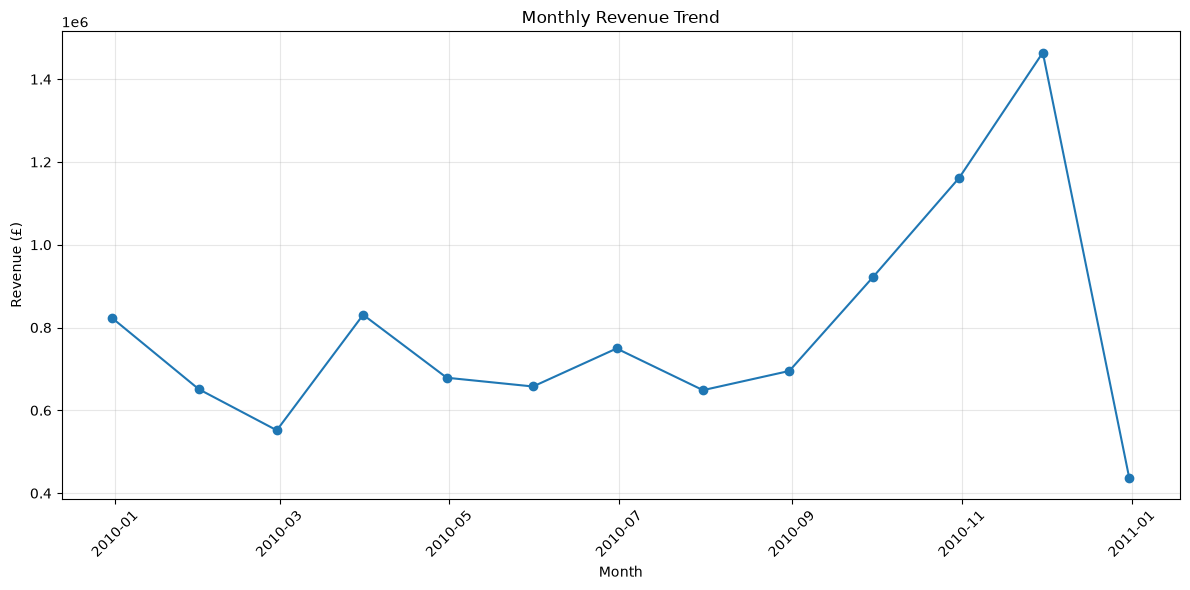

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(monthly_sales.index, monthly_sales.values, marker="o")

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

# 8. Product Analysis

Analyzed product-level sales performance to identify top revenue-generating products, product concentration, and high-value items.

In [40]:
top_products = (
    paid_sales_df.groupby("Description")["SalesValue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products)

Description
Manual                                 262963.43
REGENCY CAKESTAND 3 TIER               169912.76
WHITE HANGING HEART T-LIGHT HOLDER     160345.63
DOTCOM POSTAGE                         116408.71
ASSORTED COLOUR BIRD ORNAMENT           72890.19
PAPER CHAIN KIT 50'S CHRISTMAS          58127.30
JUMBO BAG RED RETROSPOT                 56480.46
PARTY BUNTING                           49664.12
POSTAGE                                 49477.54
ROTATING SILVER ANGELS T-LIGHT HLDR     47954.49
Name: SalesValue, dtype: float64


# 9. Product Data Validation

Validating high-revenue entries to distinguish genuine products from administrative or operational transactions before drawing product-level business conclusions.

In [41]:
manual_sales = paid_sales_df[paid_sales_df["Description"] == "Manual"]

print("Manual transaction rows:", len(manual_sales))
print("Unique stock codes:", manual_sales["StockCode"].unique())
print("Total quantity:", manual_sales["Quantity"].sum())
print("Total revenue:", round(manual_sales["SalesValue"].sum(), 2))

Manual transaction rows: 555
Unique stock codes: ['M' 'm']
Total quantity: 2769
Total revenue: 262963.43


# 10. Refined Product Performance

Excluding administrative and non-product entries from product-level rankings to ensure that product performance reflects genuine merchandise sales.

In [42]:
product_sales_df = paid_sales_df[
    ~paid_sales_df["Description"].str.strip().str.lower().eq("manual")
].copy()

top_products = (
    product_sales_df.groupby("Description")["SalesValue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products)

Description
REGENCY CAKESTAND 3 TIER               169912.76
WHITE HANGING HEART T-LIGHT HOLDER     160345.63
DOTCOM POSTAGE                         116408.71
ASSORTED COLOUR BIRD ORNAMENT           72890.19
PAPER CHAIN KIT 50'S CHRISTMAS          58127.30
JUMBO BAG RED RETROSPOT                 56480.46
PARTY BUNTING                           49664.12
POSTAGE                                 49477.54
ROTATING SILVER ANGELS T-LIGHT HLDR     47954.49
EDWARDIAN PARASOL NATURAL               36925.26
Name: SalesValue, dtype: float64


In [43]:
product_sales_df = product_sales_df[
    ~product_sales_df["Description"].str.contains("POSTAGE", case=False, na=False)
].copy()

top_products = (
    product_sales_df.groupby("Description")["SalesValue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products)

Description
REGENCY CAKESTAND 3 TIER               169912.76
WHITE HANGING HEART T-LIGHT HOLDER     160345.63
ASSORTED COLOUR BIRD ORNAMENT           72890.19
PAPER CHAIN KIT 50'S CHRISTMAS          58127.30
JUMBO BAG RED RETROSPOT                 56480.46
PARTY BUNTING                           49664.12
ROTATING SILVER ANGELS T-LIGHT HLDR     47954.49
EDWARDIAN PARASOL NATURAL               36925.26
JUMBO BAG STRAWBERRY                    36732.16
VINTAGE UNION JACK BUNTING              36023.71
Name: SalesValue, dtype: float64


In [44]:
top10_revenue = top_products.sum()
total_product_revenue = product_sales_df["SalesValue"].sum()

top10_contribution = (top10_revenue / total_product_revenue) * 100

print("Top 10 product revenue:", round(top10_revenue, 2))
print("Total product revenue:", round(total_product_revenue, 2))
print("Top 10 revenue contribution:", round(top10_contribution, 2), "%")

Top 10 product revenue: 725056.08
Total product revenue: 9843286.55
Top 10 revenue contribution: 7.37 %


In [45]:
total_unique_products = product_sales_df["Description"].nunique()
top10_product_share = (10 / total_unique_products) * 100

print("Unique revenue-generating products:", total_unique_products)
print("Top 10 product share of catalog:", round(top10_product_share, 2), "%")
print("Top 10 revenue contribution:", round(top10_contribution, 2), "%")

Unique revenue-generating products: 4531
Top 10 product share of catalog: 0.22 %
Top 10 revenue contribution: 7.37 %


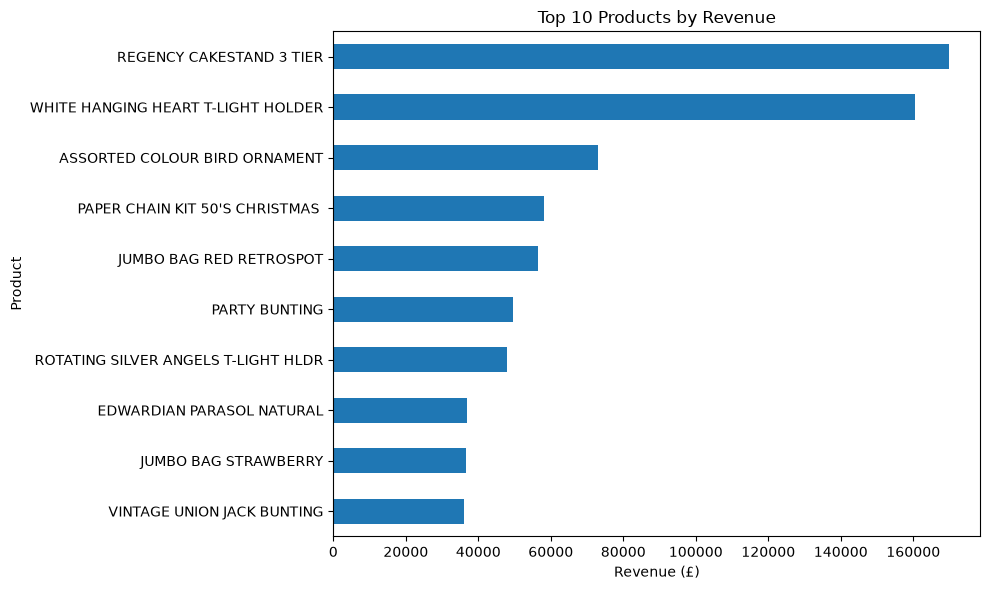

In [46]:
import matplotlib.pyplot as plt

top_products.sort_values().plot(kind="barh", figsize=(10, 6))
plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

In [47]:
product_metrics = (
    product_sales_df.groupby("Description")
    .agg(TotalQuantity=("Quantity", "sum"),
         Revenue=("SalesValue", "sum"))
    .sort_values("Revenue", ascending=False)
)

print(product_metrics.head(10))

                                     TotalQuantity    Revenue
Description                                                  
REGENCY CAKESTAND 3 TIER                     13685  169912.76
WHITE HANGING HEART T-LIGHT HOLDER           58691  160345.63
ASSORTED COLOUR BIRD ORNAMENT                45228   72890.19
PAPER CHAIN KIT 50'S CHRISTMAS               17205   58127.30
JUMBO BAG RED RETROSPOT                      30746   56480.46
PARTY BUNTING                                10079   49664.12
ROTATING SILVER ANGELS T-LIGHT HLDR          23037   47954.49
EDWARDIAN PARASOL NATURAL                     7469   36925.26
JUMBO BAG STRAWBERRY                         20002   36732.16
VINTAGE UNION JACK BUNTING                    4144   36023.71


In [48]:
product_metrics["AvgSellingPrice"] = (
    product_metrics["Revenue"] / product_metrics["TotalQuantity"]
)

top10_metrics = product_metrics.head(10).copy()

print(top10_metrics[["TotalQuantity", "Revenue", "AvgSellingPrice"]].round(2))

                                     TotalQuantity    Revenue  AvgSellingPrice
Description                                                                   
REGENCY CAKESTAND 3 TIER                     13685  169912.76            12.42
WHITE HANGING HEART T-LIGHT HOLDER           58691  160345.63             2.73
ASSORTED COLOUR BIRD ORNAMENT                45228   72890.19             1.61
PAPER CHAIN KIT 50'S CHRISTMAS               17205   58127.30             3.38
JUMBO BAG RED RETROSPOT                      30746   56480.46             1.84
PARTY BUNTING                                10079   49664.12             4.93
ROTATING SILVER ANGELS T-LIGHT HLDR          23037   47954.49             2.08
EDWARDIAN PARASOL NATURAL                     7469   36925.26             4.94
JUMBO BAG STRAWBERRY                         20002   36732.16             1.84
VINTAGE UNION JACK BUNTING                    4144   36023.71             8.69


In [49]:
highest_volume_product = product_metrics["TotalQuantity"].idxmax()
highest_value_product = product_metrics["AvgSellingPrice"].idxmax()

print("Highest-volume product:", highest_volume_product)
print("Units sold:", product_metrics.loc[highest_volume_product, "TotalQuantity"])
print("Highest average-price product:", highest_value_product)
print("Average selling price:", round(product_metrics.loc[highest_value_product, "AvgSellingPrice"], 2))

Highest-volume product: WHITE HANGING HEART T-LIGHT HOLDER
Units sold: 58691
Highest average-price product: AMAZON FEE
Average selling price: 10124.02


In [50]:
suspicious_descriptions = product_metrics[
    product_metrics.index.str.contains(
        "FEE|DISCOUNT|CARRIAGE|CHARGE|BANK|POSTAGE|MANUAL",
        case=False,
        na=False
    )
]

print(suspicious_descriptions.sort_values("Revenue", ascending=False).head(20))

                                     TotalQuantity   Revenue  AvgSellingPrice
Description                                                                  
AMAZON FEE                                       2  20248.04     10124.020000
KENSINGTON COFFEE SET                         1547  13566.81         8.769754
RETRO COFFEE MUGS ASSORTED                    4911   7710.05         1.569955
CERAMIC STRAWBERRY CAKE MONEY BANK            5093   7467.04         1.466138
COFFEE MUG CAT + BIRD DESIGN                  2899   7418.83         2.559100
SET 3 RED SPOT TIN TEA,COFFEE,SUGAR           1500   7404.09         4.936060
COFFEE MUG DOG + BALL DESIGN                  2663   6685.99         2.510698
CARRIAGE                                       131   6625.00        50.572519
COFFEE MUG APPLES DESIGN                      2623   6363.38         2.425993
CERAMIC HEART FAIRY CAKE MONEY BANK           3352   5656.15         1.687396
COFFEE MUG PEARS  DESIGN                      2597   5358.16    

In [51]:
for item in ["AMAZON FEE", "CARRIAGE"]:
    temp = paid_sales_df[paid_sales_df["Description"] == item]
    print("\n", item)
    print("Stock codes:", temp["StockCode"].unique())
    print("Rows:", len(temp))
    print("Revenue:", round(temp["SalesValue"].sum(), 2))


 AMAZON FEE
Stock codes: ['AMAZONFEE']
Rows: 2
Revenue: 20248.04

 CARRIAGE
Stock codes: ['C2']
Rows: 131
Revenue: 6625.0


In [52]:
product_sales_df = product_sales_df[
    ~product_sales_df["Description"].isin(["AMAZON FEE", "CARRIAGE"])
].copy()

product_metrics = (
    product_sales_df.groupby("Description")
    .agg(TotalQuantity=("Quantity", "sum"),
         Revenue=("SalesValue", "sum"))
)

product_metrics["AvgSellingPrice"] = (
    product_metrics["Revenue"] / product_metrics["TotalQuantity"]
)

print("Clean product count:", product_metrics.shape[0])

Clean product count: 4529


In [53]:
highest_value_product = product_metrics["AvgSellingPrice"].idxmax()

print("Highest average-price product:", highest_value_product)
print("Average selling price:", round(product_metrics.loc[highest_value_product, "AvgSellingPrice"], 2))
print("Units sold:", product_metrics.loc[highest_value_product, "TotalQuantity"])
print("Revenue:", round(product_metrics.loc[highest_value_product, "Revenue"], 2))

Highest average-price product: Adjustment by john on 26/01/2010 17
Average selling price: 410.22
Units sold: 16
Revenue: 6563.5


In [54]:
high_price_items = product_metrics[
    product_metrics["AvgSellingPrice"] > 100
].sort_values("AvgSellingPrice", ascending=False)

print(high_price_items[["TotalQuantity", "Revenue", "AvgSellingPrice"]].head(20))

                                     TotalQuantity  Revenue  AvgSellingPrice
Description                                                                 
Adjustment by john on 26/01/2010 17             16  6563.50       410.218750
VINTAGE RED KITCHEN CABINET                     17  5015.00       295.000000
VINTAGE BLUE KITCHEN CABINET                    19  5605.00       295.000000
Adjustment by Peter on Jun 25 2010               3   731.05       243.683333
RUSTIC  SEVENTEEN DRAWER SIDEBOARD               6   950.00       158.333333
GIANT SEVENTEEN DRAWER SIDEBOARD                 8  1240.00       155.000000
REGENCY MIRROR WITH SHUTTERS                     8  1200.00       150.000000
Adjustment by john on 26/01/2010 16             20  2334.43       116.721500
FRENCH STYLE WALL DRESSER                       15  1740.00       116.000000
CHEST NATURAL WOOD 20 DRAWERS                    8   910.00       113.750000
ANT WHITE SWEETHEART TABLE W 3 DRAW              3   320.00       106.666667

In [55]:
adjustment_mask = product_metrics.index.str.contains(
    "Adjustment by", case=False, na=False
)

product_metrics_clean = product_metrics[~adjustment_mask].copy()

print("Products after removing adjustments:", len(product_metrics_clean))
print(product_metrics_clean["AvgSellingPrice"].idxmax())

Products after removing adjustments: 4526
VINTAGE BLUE KITCHEN CABINET


In [56]:
highest_value_product = product_metrics_clean["AvgSellingPrice"].idxmax()

print("Product:", highest_value_product)
print("Average selling price:", round(product_metrics_clean.loc[highest_value_product, "AvgSellingPrice"], 2))
print("Units sold:", product_metrics_clean.loc[highest_value_product, "TotalQuantity"])
print("Revenue:", round(product_metrics_clean.loc[highest_value_product, "Revenue"], 2))

Product: VINTAGE BLUE KITCHEN CABINET
Average selling price: 295.0
Units sold: 19
Revenue: 5605.0


In [57]:
product_performance = product_metrics_clean[
    ["TotalQuantity", "Revenue", "AvgSellingPrice"]
].copy()

print(product_performance.sort_values("Revenue", ascending=False).head(10))

                                     TotalQuantity    Revenue  AvgSellingPrice
Description                                                                   
REGENCY CAKESTAND 3 TIER                     13685  169912.76        12.415985
WHITE HANGING HEART T-LIGHT HOLDER           58691  160345.63         2.732031
ASSORTED COLOUR BIRD ORNAMENT                45228   72890.19         1.611616
PAPER CHAIN KIT 50'S CHRISTMAS               17205   58127.30         3.378512
JUMBO BAG RED RETROSPOT                      30746   56480.46         1.837002
PARTY BUNTING                                10079   49664.12         4.927485
ROTATING SILVER ANGELS T-LIGHT HLDR          23037   47954.49         2.081629
EDWARDIAN PARASOL NATURAL                     7469   36925.26         4.943802
JUMBO BAG STRAWBERRY                         20002   36732.16         1.836424
VINTAGE UNION JACK BUNTING                    4144   36023.71         8.692980


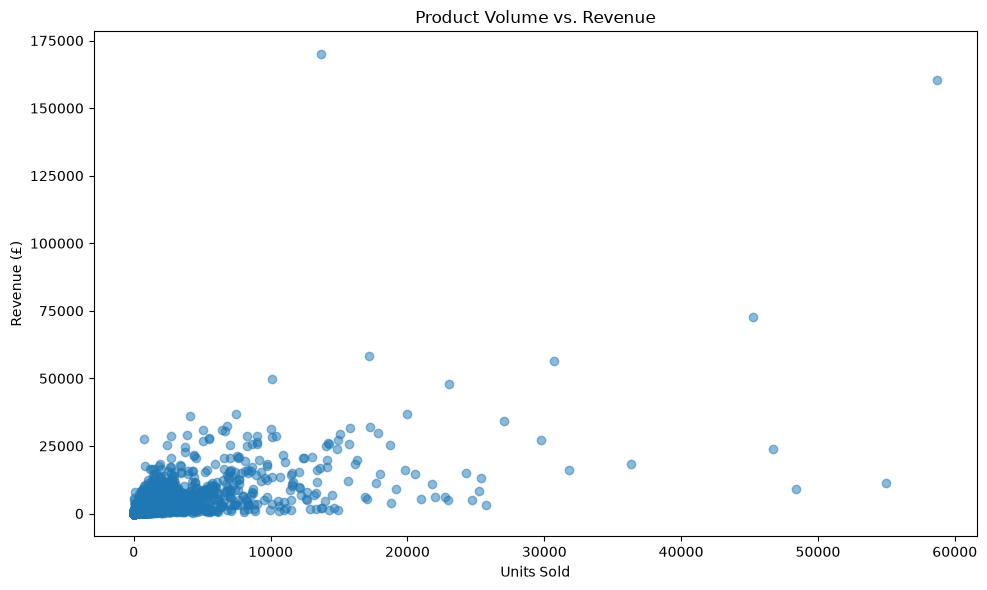

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(
    product_performance["TotalQuantity"],
    product_performance["Revenue"],
    alpha=0.5
)
plt.title("Product Volume vs. Revenue")
plt.xlabel("Units Sold")
plt.ylabel("Revenue (£)")
plt.tight_layout()
plt.show()

In [59]:
correlation = product_performance["TotalQuantity"].corr(
    product_performance["Revenue"]
)

print("Correlation between units sold and revenue:", round(correlation, 3))
print("Interpretation:", "Strong positive relationship" if correlation >= 0.7
      else "Moderate positive relationship" if correlation >= 0.4
      else "Weak positive relationship" if correlation >= 0
      else "Negative relationship")

Correlation between units sold and revenue: 0.626
Interpretation: Moderate positive relationship


In [60]:
product_performance["VolumeScore"] = product_performance["TotalQuantity"].rank(pct=True)
product_performance["RevenueScore"] = product_performance["Revenue"].rank(pct=True)
product_performance["OverallScore"] = (product_performance["VolumeScore"] + product_performance["RevenueScore"]) / 2

print(product_performance.sort_values("OverallScore", ascending=False).head(10))

                                     TotalQuantity    Revenue  \
Description                                                     
WHITE HANGING HEART T-LIGHT HOLDER           58691  160345.63   
ASSORTED COLOUR BIRD ORNAMENT                45228   72890.19   
JUMBO BAG RED RETROSPOT                      30746   56480.46   
STRAWBERRY CERAMIC TRINKET BOX               27059   34411.68   
ROTATING SILVER ANGELS T-LIGHT HLDR          23037   47954.49   
JUMBO BAG STRAWBERRY                         20002   36732.16   
PAPER CHAIN KIT 50'S CHRISTMAS               17205   58127.30   
SMALL POPCORN HOLDER                         29773   27022.23   
JUMBO  BAG BAROQUE BLACK WHITE               17270   32140.99   
LUNCH BAG RED SPOTTY                         17885   29773.27   

                                     AvgSellingPrice  VolumeScore  \
Description                                                         
WHITE HANGING HEART T-LIGHT HOLDER          2.732031     1.000000   
ASSORTED COL

In [61]:
volume_median = product_performance["TotalQuantity"].median()
revenue_median = product_performance["Revenue"].median()

product_performance["PerformanceSegment"] = "Low Volume / Low Revenue"
product_performance.loc[
    (product_performance["TotalQuantity"] >= volume_median) &
    (product_performance["Revenue"] >= revenue_median),
    "PerformanceSegment"
] = "High Volume / High Revenue"

In [62]:
print("Median units sold:", volume_median)
print("Median revenue:", round(revenue_median, 2))
print(product_performance["PerformanceSegment"].value_counts())

Median units sold: 328.5
Median revenue: 604.38
PerformanceSegment
Low Volume / Low Revenue      2616
High Volume / High Revenue    1910
Name: count, dtype: int64


In [63]:
product_performance.loc[
    (product_performance["TotalQuantity"] >= volume_median) &
    (product_performance["Revenue"] < revenue_median),
    "PerformanceSegment"
] = "High Volume / Low Revenue"

product_performance.loc[
    (product_performance["TotalQuantity"] < volume_median) &
    (product_performance["Revenue"] >= revenue_median),
    "PerformanceSegment"
] = "Low Volume / High Revenue"

print(product_performance["PerformanceSegment"].value_counts())

PerformanceSegment
High Volume / High Revenue    1910
Low Volume / Low Revenue      1910
Low Volume / High Revenue      353
High Volume / Low Revenue      353
Name: count, dtype: int64


In [64]:
segment_top_products = (
    product_performance
    .sort_values(["PerformanceSegment", "Revenue"], ascending=[True, False])
    .groupby("PerformanceSegment")
    .head(3)
)

print(segment_top_products[
    ["TotalQuantity", "Revenue", "AvgSellingPrice", "PerformanceSegment"]
])

                                    TotalQuantity    Revenue  AvgSellingPrice  \
Description                                                                     
REGENCY CAKESTAND 3 TIER                    13685  169912.76        12.415985   
WHITE HANGING HEART T-LIGHT HOLDER          58691  160345.63         2.732031   
ASSORTED COLOUR BIRD ORNAMENT               45228   72890.19         1.611616   
PARTY INVITES BALLOON GIRL                    883     603.46         0.683420   
ORANGE FLOWER MUG                            5394     603.45         0.111874   
DAISY JOURNAL                                 362     601.45         1.661464   
VINTAGE POST OFFICE CABINET                   123    7954.87        64.673740   
VINTAGE BLUE KITCHEN CABINET                   19    5605.00       295.000000   
CREAM SWEETHEART MAGAZINE RACK                308    5426.74        17.619286   
YELLOW DRAGONFLY HELICOPTER                    75     603.54         8.047200   
RED DRAGONFLY HELICOPTER    

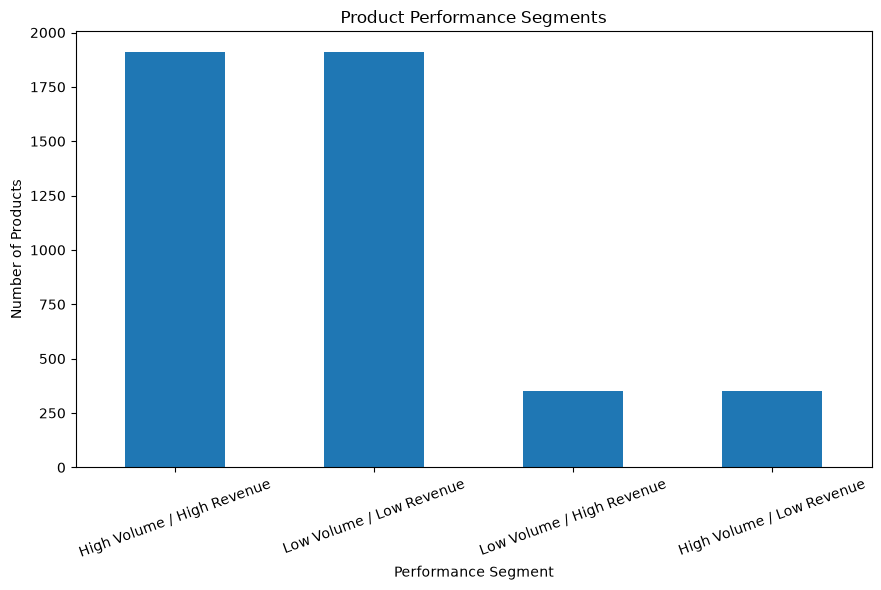

In [65]:
segment_counts = product_performance["PerformanceSegment"].value_counts()

segment_counts.plot(kind="bar", figsize=(9, 6))
plt.title("Product Performance Segments")
plt.xlabel("Performance Segment")
plt.ylabel("Number of Products")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Customer Metrics & RFM Prep 

In [66]:
customer_metrics = (
    customer_sales_df.groupby("Customer ID")
    .agg(
        Revenue=("SalesValue", "sum"),
        Orders=("Invoice", "nunique"),
        Units=("Quantity", "sum")
    )
)

print(customer_metrics.sort_values("Revenue", ascending=False).head(10))

               Revenue  Orders   Units
Customer ID                           
18102.0      349164.35      89  124216
14646.0      248396.50      78  170278
14156.0      196549.74     102  108105
14911.0      152121.22     205   69709
13694.0      131443.19      94  125893
17511.0       84541.17      31   55107
15061.0       83284.38      86   51791
16684.0       80489.21      27   54555
16754.0       65500.07      29   63551
17949.0       60117.60      74   30112


In [67]:
customer_metrics["RevenueShare"] = (
    customer_metrics["Revenue"] / customer_metrics["Revenue"].sum() * 100
)

top_10_customer_share = (
    customer_metrics.nlargest(10, "Revenue")["Revenue"].sum()
    / customer_metrics["Revenue"].sum() * 100
)

print("Total identified-customer revenue:", round(customer_metrics["Revenue"].sum(), 2))
print("Top 10 customer revenue:", round(customer_metrics.nlargest(10, "Revenue")["Revenue"].sum(), 2))
print("Top 10 customer revenue share:", round(top_10_customer_share, 2), "%")

Total identified-customer revenue: 8798233.74
Top 10 customer revenue: 1451607.43
Top 10 customer revenue share: 16.5 %


In [68]:
print("Average customer revenue:", round(customer_metrics["Revenue"].mean(), 2))
print("Median customer revenue:", round(customer_metrics["Revenue"].median(), 2))
print("Highest customer revenue:", round(customer_metrics["Revenue"].max(), 2))

Average customer revenue: 2040.41
Median customer revenue: 701.62
Highest customer revenue: 349164.35


In [69]:
customer_metrics["AvgOrderValue"] = (
    customer_metrics["Revenue"] / customer_metrics["Orders"]
)

print(customer_metrics.sort_values("Orders", ascending=False).head(10))

               Revenue  Orders   Units  RevenueShare  AvgOrderValue
Customer ID                                                        
14911.0      152121.22     205   69709      1.728997     742.054732
17850.0       51208.87     155   21052      0.582036     330.379806
12748.0       22457.90     144   13109      0.255255     155.957639
15311.0       55942.74     121   32784      0.635841     462.336694
13089.0       57885.45     109   29125      0.657921     531.059174
14606.0       18482.10     102    9287      0.210066     181.197059
14156.0      196549.74     102  108105      2.233968    1926.958235
13694.0      131443.19      94  125893      1.493972    1398.331809
17841.0       29562.02      91   14332      0.335999     324.857363
18102.0      349164.35      89  124216      3.968573    3923.194944


In [70]:
order_revenue_corr = customer_metrics["Orders"].corr(customer_metrics["Revenue"])

print("Correlation between orders and revenue:", round(order_revenue_corr, 3))

Correlation between orders and revenue: 0.656


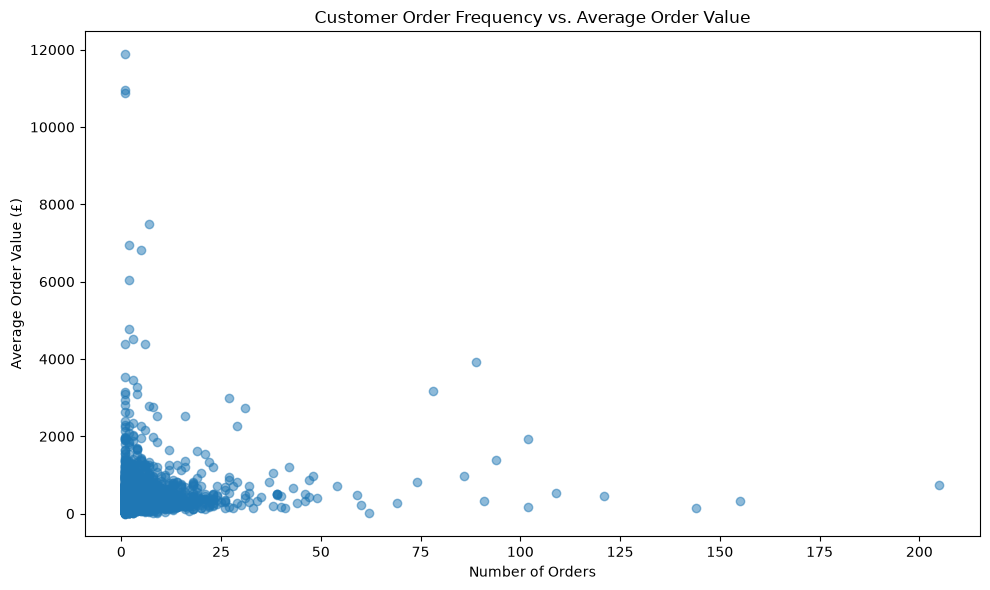

In [71]:
plt.figure(figsize=(10, 6))

plt.scatter(
    customer_metrics["Orders"],
    customer_metrics["AvgOrderValue"],
    alpha=0.5
)

plt.title("Customer Order Frequency vs. Average Order Value")
plt.xlabel("Number of Orders")
plt.ylabel("Average Order Value (£)")
plt.tight_layout()
plt.show()

In [72]:
order_aov_corr = customer_metrics["Orders"].corr(
    customer_metrics["AvgOrderValue"]
)

print("Correlation between orders and average order value:", round(order_aov_corr, 3))

Correlation between orders and average order value: 0.09


In [73]:
customer_metrics["LastPurchase"] = customer_sales_df.groupby("Customer ID")["InvoiceDate"].max()

analysis_date = customer_sales_df["InvoiceDate"].max()

customer_metrics["RecencyDays"] = (
    analysis_date - customer_metrics["LastPurchase"]
).dt.days

print(customer_metrics[["Revenue", "Orders", "RecencyDays"]].head())

             Revenue  Orders  RecencyDays
Customer ID                              
12346.0       372.86      11          164
12347.0      1323.32       2            2
12348.0       222.16       1           73
12349.0      2671.14       3           42
12351.0       300.93       1           10


## RFM Scoring and Segments

In [74]:
customer_metrics["RecencyScore"] = pd.qcut(
    customer_metrics["RecencyDays"], 5, labels=[5, 4, 3, 2, 1]
)

customer_metrics["FrequencyScore"] = pd.qcut(
    customer_metrics["Orders"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]
)

customer_metrics["MonetaryScore"] = pd.qcut(
    customer_metrics["Revenue"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]
)

print(customer_metrics[[
    "RecencyScore", "FrequencyScore", "MonetaryScore"
]].head())

            RecencyScore FrequencyScore MonetaryScore
Customer ID                                          
12346.0                2              5             2
12347.0                5              2             4
12348.0                2              1             1
12349.0                3              3             5
12351.0                5              1             2


In [75]:
customer_metrics["RFMScore"] = (
    customer_metrics["RecencyScore"].astype(int)
    + customer_metrics["FrequencyScore"].astype(int)
    + customer_metrics["MonetaryScore"].astype(int)
)

print(
    customer_metrics.sort_values("RFMScore", ascending=False)
    [["RecencyScore", "FrequencyScore", "MonetaryScore", "RFMScore"]]
    .head(10)
)

            RecencyScore FrequencyScore MonetaryScore  RFMScore
Customer ID                                                    
14606.0                5              5             5        15
14667.0                5              5             5        15
14680.0                5              5             5        15
12415.0                5              5             5        15
18225.0                5              5             5        15
18226.0                5              5             5        15
18229.0                5              5             5        15
14702.0                5              5             5        15
14709.0                5              5             5        15
14713.0                5              5             5        15


In [76]:
customer_metrics["RFMSegment"] = pd.cut(
    customer_metrics["RFMScore"],
    bins=[0, 6, 9, 12, 15],
    labels=["At Risk / Low Engagement", "Needs Attention", "Loyal / High Potential", "Champions"]
)

print(customer_metrics["RFMSegment"].value_counts().sort_index())

RFMSegment
At Risk / Low Engagement    1241
Needs Attention             1126
Loyal / High Potential      1025
Champions                    920
Name: count, dtype: int64


In [77]:
segment_revenue = (
    customer_metrics.groupby("RFMSegment", observed=True)["Revenue"]
    .agg(["sum", "mean", "count"])
    .sort_values("sum", ascending=False)
)

print(segment_revenue)

                                  sum         mean  count
RFMSegment                                               
Champions                 5950360.088  6467.782704    920
Loyal / High Potential    1721931.782  1679.933446   1025
Needs Attention            798905.062   709.507160   1126
At Risk / Low Engagement   327036.812   263.526843   1241


In [78]:
segment_revenue["RevenueShare"] = (
    segment_revenue["sum"] / segment_revenue["sum"].sum() * 100
)

print(segment_revenue[["sum", "count", "RevenueShare"]])

                                  sum  count  RevenueShare
RFMSegment                                                
Champions                 5950360.088    920     67.631303
Loyal / High Potential    1721931.782   1025     19.571335
Needs Attention            798905.062   1126      9.080289
At Risk / Low Engagement   327036.812   1241      3.717073


In [79]:
champions = customer_metrics[
    customer_metrics["RFMSegment"] == "Champions"
]

print(
    champions.sort_values("Revenue", ascending=False)
    [["Revenue", "Orders", "Units", "AvgOrderValue", "RecencyDays", "RFMScore"]]
    .head(10)
)

               Revenue  Orders   Units  AvgOrderValue  RecencyDays  RFMScore
Customer ID                                                                 
18102.0      349164.35      89  124216    3923.194944            0        15
14646.0      248396.50      78  170278    3184.570513            9        15
14156.0      196549.74     102  108105    1926.958235            6        15
14911.0      152121.22     205   69709     742.054732            0        15
13694.0      131443.19      94  125893    1398.331809            8        15
17511.0       84541.17      31   55107    2727.134516            2        15
15061.0       83284.38      86   51791     968.423023            2        15
16684.0       80489.21      27   54555    2981.081852           14        15
16754.0       65500.07      29   63551    2258.623103            7        15
17949.0       60117.60      74   30112     812.400000            6        15


## Geographic Analysis (country performance & returns) 

In [80]:
country_performance = (
    paid_sales_df.groupby("Country")
    .agg(
        Revenue=("SalesValue", "sum"),
        Orders=("Invoice", "nunique"),
        Units=("Quantity", "sum")
    )
    .sort_values("Revenue", ascending=False)
)

print(country_performance.head(10))

                    Revenue  Orders    Units
Country                                     
United Kingdom  8812685.403   19291  4702281
EIRE             380909.570     348   193047
Netherlands      268784.350     135   183615
Germany          202025.391     347   108615
France           147103.140     241   163029
Sweden            53501.990      69    52555
Denmark           50906.850      26   229690
Spain             47568.650      66    22841
Switzerland       43921.390      40    22255
Australia         31446.800      40    20189


In [81]:
country_performance["RevenueShare"] = (
    country_performance["Revenue"] / paid_sales_df["SalesValue"].sum() * 100
)

print(country_performance.head(10)[["Revenue", "Orders", "RevenueShare"]])
print("Top 5 country revenue share:", round(country_performance.head(5)["RevenueShare"].sum(), 2), "%")

                    Revenue  Orders  RevenueShare
Country                                          
United Kingdom  8812685.403   19291     85.792139
EIRE             380909.570     348      3.708183
Netherlands      268784.350     135      2.616635
Germany          202025.391     347      1.966732
France           147103.140     241      1.432060
Sweden            53501.990      69      0.520846
Denmark           50906.850      26      0.495582
Spain             47568.650      66      0.463084
Switzerland       43921.390      40      0.427578
Australia         31446.800      40      0.306137
Top 5 country revenue share: 95.52 %


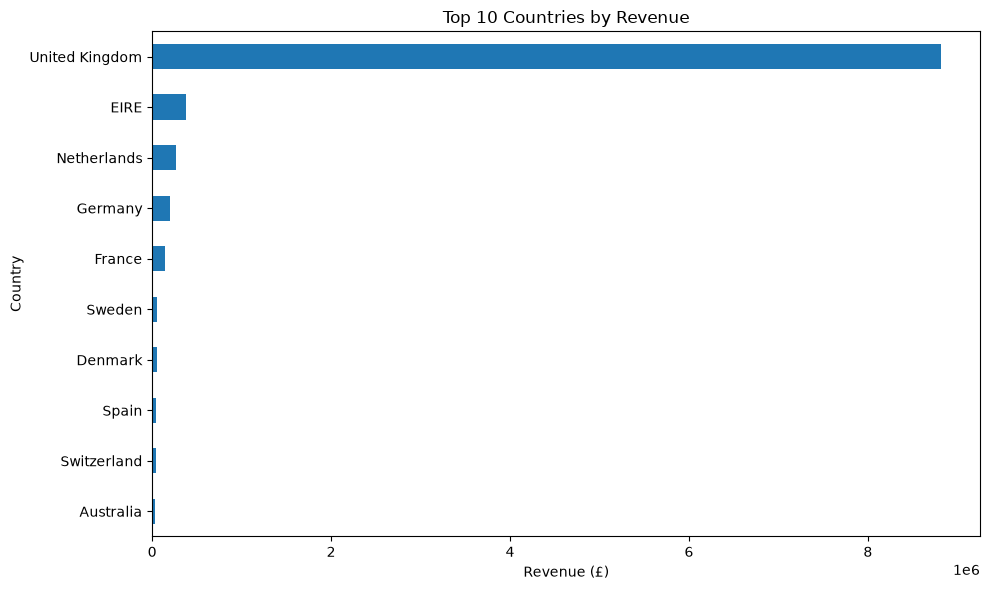

In [82]:
top_10_countries = country_performance.head(10)

top_10_countries["Revenue"].plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Country")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [83]:
country_performance["AvgOrderValue"] = (
    country_performance["Revenue"] / country_performance["Orders"]
)

print(
    country_performance.sort_values("AvgOrderValue", ascending=False)
    .head(10)[["Revenue", "Orders", "AvgOrderValue"]]
)

               Revenue  Orders  AvgOrderValue
Country                                      
Norway        23944.18      11    2176.743636
Hong Kong      8202.52       4    2050.630000
Netherlands  268784.35     135    1990.995185
Denmark       50906.85      26    1957.955769
Israel         3199.40       2    1599.700000
Thailand       3070.54       2    1535.270000
Malta          5373.50       4    1343.375000
RSA            3802.01       3    1267.336667
Bermuda        1253.14       1    1253.140000
Greece        14335.67      13    1102.743846


In [84]:
meaningful_markets = country_performance[
    country_performance["Orders"] >= 20
].sort_values("AvgOrderValue", ascending=False)

print(
    meaningful_markets.head(10)
    [["Revenue", "Orders", "AvgOrderValue"]]
)

                   Revenue  Orders  AvgOrderValue
Country                                          
Netherlands      268784.35     135    1990.995185
Denmark           50906.85      26    1957.955769
Switzerland       43921.39      40    1098.034750
EIRE             380909.57     348    1094.567730
Channel Islands   24546.32      30     818.210667
Australia         31446.80      40     786.170000
Sweden            53501.99      69     775.391159
Spain             47568.65      66     720.737121
France           147103.14     241     610.386473
Portugal          24265.00      41     591.829268


## Product Returns Analysis (units, value, cancellation)

In [85]:
product_sales = paid_sales_df.groupby(
    paid_sales_df["Description"].astype(str)
)["Quantity"].sum()

product_returns = returns_df.groupby(
    returns_df["Description"].astype(str)
)["Quantity"].sum().abs()

product_return_analysis = pd.DataFrame({
    "UnitsSold": product_sales,
    "UnitsReturned": product_returns
}).fillna(0)

In [86]:
product_return_analysis["ReturnRate"] = (
    product_return_analysis["UnitsReturned"]
    / product_return_analysis["UnitsSold"] * 100
)

print(
    product_return_analysis
    .sort_values("ReturnRate", ascending=False)
    .head(10)
)

                                     UnitsSold  UnitsReturned  ReturnRate
Description                                                              
wonky bottom/broken                        0.0           35.0         inf
wrong code                                 0.0          258.0         inf
missing                                    0.0        15149.0         inf
missing (wrongly coded?)                   0.0         2127.0         inf
missing?                                   0.0          716.0         inf
Given away                                 0.0         8800.0         inf
HAND OPEN SHAPE CHROME                     0.0            3.0         inf
Incorrectly entered. should be 2279        0.0          720.0         inf
LARGE GLASS HEART TRINKET POT              0.0            4.0         inf
LARGE SILVER BALUSTRADE CANDLESTICK        0.0            1.0         inf


In [87]:
product_return_analysis = product_return_analysis[
    product_return_analysis["UnitsSold"] > 0
].copy()

print("Products with recorded sales:", len(product_return_analysis))
print(product_return_analysis.sort_values("ReturnRate", ascending=False).head(10))

Products with recorded sales: 4534
                                    UnitsSold  UnitsReturned   ReturnRate
Description                                                              
SAMPLES                                   1.0           40.0  4000.000000
WHITE SCANDINAVIAN HEART CHRISTMAS        1.0           12.0  1200.000000
Discount                                196.0         1874.0   956.122449
FEATHER HEART LIGHTS                      1.0            9.0   900.000000
AMAZON FEE                                2.0            7.0   350.000000
RED HEART CANDY POP LIGHTS                1.0            3.0   300.000000
SILVER CHERRY LIGHTS                     60.0          153.0   255.000000
Bank Charges                             21.0           48.0   228.571429
 Bank Charges                             2.0            4.0   200.000000
CREAM SWEETHEART DOUBLE SHELF             3.0            6.0   200.000000


In [88]:
meaningful_returns = product_return_analysis[
    product_return_analysis["UnitsSold"] >= 100
].copy()

print("Products with at least 100 units sold:", len(meaningful_returns))
print(
    meaningful_returns
    .sort_values("ReturnRate", ascending=False)
    .head(10)
)

Products with at least 100 units sold: 3094
                              UnitsSold  UnitsReturned  ReturnRate
Description                                                       
Discount                          196.0         1874.0  956.122449
WHITE CHERRY LIGHTS               978.0         1064.0  108.793456
BLACK CHERRY LIGHTS               234.0          240.0  102.564103
LITTLE FLOWER SHOPPER BAG         400.0          400.0  100.000000
MULTICOLOUR POLKADOT PLATE        684.0          684.0  100.000000
RED POLKADOT PUDDING BOWL        3686.0         3648.0   98.969072
BLUE POLKADOT PUDDING BOWL       2545.0         2496.0   98.074656
LARGE RED RETROSPOT WINDMILL      753.0          724.0   96.148738
ROSES ON BLUE TEACUP CANDLE       539.0          504.0   93.506494
BLUE POLKADOT PURSE               372.0          330.0   88.709677


In [89]:
high_volume_returns = meaningful_returns[
    meaningful_returns["UnitsSold"] >= 1000
].copy()

print("Products with at least 1,000 units sold:", len(high_volume_returns))
print(
    high_volume_returns
    .sort_values("ReturnRate", ascending=False)
    .head(10)
)

Products with at least 1,000 units sold: 1270
                                   UnitsSold  UnitsReturned  ReturnRate
Description                                                            
RED POLKADOT PUDDING BOWL             3686.0         3648.0   98.969072
BLUE POLKADOT PUDDING BOWL            2545.0         2496.0   98.074656
RETROSPOT PARTY BAG + STICKER SET     1291.0          771.0   59.721146
Manual                                2769.0         1384.0   49.981943
BLUE/PINK NEST STRIPE BOX             1142.0          567.0   49.649737
SET 4 NURSERY DES ROUND BOXES         2994.0         1480.0   49.432198
BLACK BIRD GARDEN DESIGN MUG          6050.0         2979.0   49.239669
YELLOW BREAKFAST CUP AND SAUCER       2661.0         1309.0   49.192033
ARMY CAMO WRAPPING TAPE               2251.0         1104.0   49.044869
BLUE BREAKFAST CUP AND SAUCER         2008.0          984.0   49.003984


In [90]:
product_returns_clean = high_volume_returns[
    ~high_volume_returns.index.isin(["Manual", "Discount"])
].copy()

print(
    product_returns_clean
    .sort_values("ReturnRate", ascending=False)
    .head(10)
)

                                   UnitsSold  UnitsReturned  ReturnRate
Description                                                            
RED POLKADOT PUDDING BOWL             3686.0         3648.0   98.969072
BLUE POLKADOT PUDDING BOWL            2545.0         2496.0   98.074656
RETROSPOT PARTY BAG + STICKER SET     1291.0          771.0   59.721146
BLUE/PINK NEST STRIPE BOX             1142.0          567.0   49.649737
SET 4 NURSERY DES ROUND BOXES         2994.0         1480.0   49.432198
BLACK BIRD GARDEN DESIGN MUG          6050.0         2979.0   49.239669
YELLOW BREAKFAST CUP AND SAUCER       2661.0         1309.0   49.192033
ARMY CAMO WRAPPING TAPE               2251.0         1104.0   49.044869
BLUE BREAKFAST CUP AND SAUCER         2008.0          984.0   49.003984
WHITE BIRD GARDEN DESIGN MUG          8817.0         4320.0   48.996257


In [91]:
return_revenue = (
    returns_df.groupby(returns_df["Description"].astype(str))["SalesValue"]
    .sum()
    .abs()
)

product_returns_clean["ReturnValue"] = (
    product_returns_clean.index.to_series().map(return_revenue).fillna(0)
)

print(
    product_returns_clean
    .sort_values("ReturnValue", ascending=False)
    .head(10)
)

                                    UnitsSold  UnitsReturned  ReturnRate  \
Description                                                                
REGENCY CAKESTAND 3 TIER              13685.0          611.0    4.464742   
PINK CHERRY LIGHTS                     2277.0          685.0   30.083443   
BAKING SET 9 PIECE RETROSPOT           4429.0          795.0   17.949876   
COLOUR GLASS. STAR T-LIGHT HOLDER      8971.0         1349.0   15.037343   
SMALL FAIRY CAKE FRIDGE MAGNETS       12236.0         2513.0   20.537757   
POSTAGE                                2310.0          156.0    6.753247   
WHITE HANGING HEART T-LIGHT HOLDER    58691.0         1060.0    1.806069   
LIGHT PINK CHERRY LIGHTS               1433.0          458.0   31.960921   
SMALL GLASS HEART TRINKET POT          7401.0         1092.0   14.754763   
RED RETROSPOT CAKE STAND               2758.0          185.0    6.707759   

                                    ReturnValue  
Description                          

In [92]:
overall_units_sold = paid_sales_df["Quantity"].sum()
overall_units_returned = abs(returns_df["Quantity"].sum())

overall_unit_return_rate = (
    overall_units_returned / overall_units_sold * 100
)

In [93]:
print("Total units sold:", overall_units_sold)
print("Total units returned:", overall_units_returned)
print("Overall unit return rate:", round(overall_unit_return_rate, 2), "%")

Total units sold: 5812948
Total units returned: 579417
Overall unit return rate: 9.97 %


In [94]:
top_returned_products = (
    product_returns_clean
    .sort_values("UnitsReturned", ascending=False)
    .head(10)
)

print(top_returned_products[["UnitsSold", "UnitsReturned", "ReturnRate", "ReturnValue"]])

                                     UnitsSold  UnitsReturned  ReturnRate  \
Description                                                                 
ROTATING SILVER ANGELS T-LIGHT HLDR    23037.0         9374.0   40.691062   
SET/6 FRUIT SALAD PAPER CUPS           14937.0         7128.0   47.720426   
SET/6 FRUIT SALAD  PAPER PLATES        14660.0         7008.0   47.803547   
POP ART PEN CASE & PENS                10612.0         5184.0   48.850358   
BLACK SILVER FLOWER T-LIGHT HOLDER     11520.0         5040.0   43.750000   
MULTICOLOUR SPRING FLOWER MUG          11130.0         4993.0   44.860737   
TEATIME PEN CASE & PENS                 9992.0         4632.0   46.357086   
WHITE BIRD GARDEN DESIGN MUG            8817.0         4320.0   48.996257   
S/4 BLUE ROUND DECOUPAGE BOXES          8312.0         3940.0   47.401347   
THE KING GIFT BAG                       8081.0         3744.0   46.330900   

                                     ReturnValue  
Description             

In [95]:
high_impact_returns = product_returns_clean[
    product_returns_clean["ReturnValue"] >= 1000
].copy()

print("Products with return value >= £1,000:", len(high_impact_returns))
print(
    high_impact_returns
    .sort_values("ReturnRate", ascending=False)
    .head(10)
)

Products with return value >= £1,000: 34
                                   UnitsSold  UnitsReturned  ReturnRate  \
Description                                                               
RETROSPOT PARTY BAG + STICKER SET     1291.0          771.0   59.721146   
S/4 BLUE ROUND DECOUPAGE BOXES        8312.0         3940.0   47.401347   
FRENCH WC SIGN BLUE METAL             2608.0         1155.0   44.286810   
LOVE GARLAND PAINTED ZINC             3028.0         1196.0   39.498018   
LIGHT PINK CHERRY LIGHTS              1433.0          458.0   31.960921   
PINK CHERRY LIGHTS                    2277.0          685.0   30.083443   
PAPER CHAIN KIT SKULLS                1997.0          585.0   29.293941   
GLITTER HANGING BUTTERFLY STRING      3528.0          975.0   27.636054   
FRYING PAN RED POLKADOT               1209.0          275.0   22.746071   
SMALL FAIRY CAKE FRIDGE MAGNETS      12236.0         2513.0   20.537757   

                                   ReturnValue  
Descripti

In [96]:
paid_sales_df["DayOfWeek"] = paid_sales_df["InvoiceDate"].dt.day_name()

weekday_sales = (
    paid_sales_df.groupby("DayOfWeek")["SalesValue"]
    .agg(["sum", "count"])
)

In [97]:
weekday_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

weekday_sales = weekday_sales.reindex(weekday_order)

print(weekday_sales)

                   sum  count
DayOfWeek                    
Monday     1860809.825  90906
Tuesday    2002003.301  90522
Wednesday  1745382.103  87146
Thursday   2097097.802  95039
Friday     1533319.022  68542
Saturday      9803.050    400
Sunday     1023721.131  72176


In [98]:
weekday_sales["AvgTransactionValue"] = (
    weekday_sales["sum"] / weekday_sales["count"]
)

print(
    weekday_sales[["sum", "count", "AvgTransactionValue"]]
)

                   sum  count  AvgTransactionValue
DayOfWeek                                         
Monday     1860809.825  90906            20.469604
Tuesday    2002003.301  90522            22.116207
Wednesday  1745382.103  87146            20.028253
Thursday   2097097.802  95039            22.065655
Friday     1533319.022  68542            22.370503
Saturday      9803.050    400            24.507625
Sunday     1023721.131  72176            14.183678


In [99]:
monthly_orders = (
    paid_sales_df
    .set_index("InvoiceDate")
    .resample("ME")["Invoice"]
    .nunique()
)

print(monthly_orders)

InvoiceDate
2009-12-31    1682
2010-01-31    1105
2010-02-28    1202
2010-03-31    1681
2010-04-30    1462
2010-05-31    1500
2010-06-30    1645
2010-07-31    1529
2010-08-31    1425
2010-09-30    1839
2010-10-31    2301
2010-11-30    2747
2010-12-31     834
Freq: ME, Name: Invoice, dtype: int64


In [100]:
monthly_aov = monthly_sales / monthly_orders

In [101]:
print(monthly_aov.round(2))

InvoiceDate
2009-12-31    488.99
2010-01-31    589.28
2010-02-28    459.13
2010-03-31    494.30
2010-04-30    464.35
2010-05-31    438.47
2010-06-30    455.65
2010-07-31    424.34
2010-08-31    487.90
2010-09-30    501.19
2010-10-31    504.96
2010-11-30    533.05
2010-12-31    524.74
Freq: ME, dtype: float64


In [102]:
paid_sales_df["Hour"] = paid_sales_df["InvoiceDate"].dt.hour

hourly_sales = (
    paid_sales_df.groupby("Hour")["SalesValue"]
    .agg(["sum", "count"])
)

print(hourly_sales)

              sum  count
Hour                    
7       45173.360    685
8      248940.430   6879
9      811807.660  33306
10    1180711.352  42546
11    1339629.933  61321
12    1459647.691  78010
13    1330157.834  74932
14    1199013.910  71595
15    1121576.882  55357
16     884153.701  37685
17     416238.591  27756
18     136836.100   8553
19      77876.440   4921
20      20372.350   1185


In [103]:
hourly_sales["AvgTransactionValue"] = (
    hourly_sales["sum"] / hourly_sales["count"]
)

print(
    hourly_sales.sort_values(
        "AvgTransactionValue",
        ascending=False
    )
)

              sum  count  AvgTransactionValue
Hour                                         
7       45173.360    685            65.946511
8      248940.430   6879            36.188462
10    1180711.352  42546            27.751407
9      811807.660  33306            24.374217
16     884153.701  37685            23.461688
11    1339629.933  61321            21.846185
15    1121576.882  55357            20.260796
12    1459647.691  78010            18.711033
13    1330157.834  74932            17.751533
20      20372.350   1185            17.191857
14    1199013.910  71595            16.747174
18     136836.100   8553            15.998609
19      77876.440   4921            15.825328
17     416238.591  27756            14.996346


In [104]:
day_hour_sales = (
    paid_sales_df.groupby(
        [paid_sales_df["InvoiceDate"].dt.day_name(),
         paid_sales_df["InvoiceDate"].dt.hour]
    )["SalesValue"]
    .sum()
)

In [105]:
print(
    day_hour_sales
    .sort_values(ascending=False)
    .head(10)
)

InvoiceDate  InvoiceDate
Monday       16             296496.851
Wednesday    12             285541.460
Tuesday      15             273172.220
Thursday     12             270456.170
Tuesday      11             266906.880
             13             256214.190
Thursday     14             255594.960
             15             253473.300
Monday       13             250499.890
Thursday     11             247899.450
Name: SalesValue, dtype: float64


In [106]:
day_hour_stats = (
    paid_sales_df.groupby([
        paid_sales_df["InvoiceDate"].dt.day_name(),
        paid_sales_df["InvoiceDate"].dt.hour
    ])["SalesValue"]
    .agg(["sum", "count"])
)

In [107]:
day_hour_stats["AvgTransactionValue"] = (
    day_hour_stats["sum"] / day_hour_stats["count"]
)

print(
    day_hour_stats
    .sort_values("sum", ascending=False)
    .head(10)
)

                                sum  count  AvgTransactionValue
InvoiceDate InvoiceDate                                        
Monday      16           296496.851   7678            38.616417
Wednesday   12           285541.460  13709            20.828759
Tuesday     15           273172.220  10918            25.020354
Thursday    12           270456.170  11827            22.867690
Tuesday     11           266906.880   9025            29.574170
            13           256214.190  13985            18.320643
Thursday    14           255594.960  14135            18.082417
            15           253473.300   8840            28.673450
Monday      13           250499.890  13967            17.935125
Thursday    11           247899.450  10089            24.571261


In [108]:
country_analysis = (
    paid_sales_df.groupby("Country")
    .agg(
        Revenue=("SalesValue", "sum"),
        Orders=("Invoice", "nunique")
    )
)

In [109]:
country_analysis["AvgOrderValue"] = (
    country_analysis["Revenue"] / country_analysis["Orders"]
)

print(country_analysis.sort_values("Revenue", ascending=False).head(10))

                    Revenue  Orders  AvgOrderValue
Country                                           
United Kingdom  8812685.403   19291     456.828853
EIRE             380909.570     348    1094.567730
Netherlands      268784.350     135    1990.995185
Germany          202025.391     347     582.205738
France           147103.140     241     610.386473
Sweden            53501.990      69     775.391159
Denmark           50906.850      26    1957.955769
Spain             47568.650      66     720.737121
Switzerland       43921.390      40    1098.034750
Australia         31446.800      40     786.170000


In [110]:
international_markets = country_analysis[
    (country_analysis["Orders"] >= 10) &
    (country_analysis.index != "United Kingdom")
].copy()

In [111]:
print(
    international_markets
    .sort_values("AvgOrderValue", ascending=False)
    .head(10)
)

                   Revenue  Orders  AvgOrderValue
Country                                          
Norway            23944.18      11    2176.743636
Netherlands      268784.35     135    1990.995185
Denmark           50906.85      26    1957.955769
Greece            14335.67      13    1102.743846
Switzerland       43921.39      40    1098.034750
EIRE             380909.57     348    1094.567730
Channel Islands   24546.32      30     818.210667
Australia         31446.80      40     786.170000
Sweden            53501.99      69     775.391159
Spain             47568.65      66     720.737121


In [112]:
country_returns = (
    returns_df.groupby("Country")["Quantity"]
    .sum()
    .abs()
    .rename("UnitsReturned")
)

In [113]:
country_return_analysis = country_analysis.join(country_returns, how="left").fillna(0)

In [114]:
print(
    country_return_analysis
    .sort_values("UnitsReturned", ascending=False)
    .head(10)
)

                          Revenue  Orders  AvgOrderValue  UnitsReturned
Country                                                                
United Kingdom        8812685.403   19291     456.828853       471269.0
France                 147103.140     241     610.386473        88712.0
Spain                   47568.650      66     720.737121         4524.0
EIRE                   380909.570     348    1094.567730         4389.0
Denmark                 50906.850      26    1957.955769         2660.0
Netherlands            268784.350     135    1990.995185         1857.0
Germany                202025.391     347     582.205738         1607.0
Channel Islands         24546.320      30     818.210667          997.0
Japan                    9722.020      16     607.626250          707.0
United Arab Emirates     9195.350      13     707.334615          593.0


In [115]:
country_units_sold = (
    paid_sales_df.groupby("Country")["Quantity"]
    .sum()
    .rename("UnitsSold")
)

In [116]:
country_return_analysis = country_return_analysis.join(
    country_units_sold,
    how="left"
)

country_return_analysis["UnitsSold"] = (
    country_return_analysis["UnitsSold"].fillna(0)
)

country_return_analysis["ReturnRate"] = (
    country_return_analysis["UnitsReturned"]
    / country_return_analysis["UnitsSold"]
    * 100
)

country_return_analysis

,Revenue,Orders,AvgOrderValue,UnitsReturned,UnitsSold,ReturnRate
Country,,,,,,
Australia,31446.800,40,786.170000,136.0,20189,0.673634
Austria,13414.330,28,479.083214,218.0,6697,3.255189
Bahrain,2355.650,7,336.521429,10.0,1025,0.975610
Belgium,24537.580,52,471.876538,95.0,12059,0.787793
Bermuda,1253.140,1,1253.140000,0.0,2798,0.000000
Brazil,268.270,1,268.270000,0.0,189,0.000000
Canada,1216.660,2,608.330000,0.0,894,0.000000
Channel Islands,24546.320,30,818.210667,997.0,11991,8.314569
Cyprus,11347.100,21,540.338095,254.0,4610,5.509761


In [117]:
print(
    country_return_analysis[
        country_return_analysis["UnitsSold"] >= 1000
    ]
    .sort_values("ReturnRate", ascending=False)
    .head(10)
)

                          Revenue  Orders  AvgOrderValue  UnitsReturned  \
Country                                                                   
France                 147103.140     241     610.386473        88712.0   
Spain                   47568.650      66     720.737121         4524.0   
United Kingdom        8812685.403   19291     456.828853       471269.0   
Japan                    9722.020      16     607.626250          707.0   
United Arab Emirates     9195.350      13     707.334615          593.0   
Channel Islands         24546.320      30     818.210667          997.0   
Poland                   3567.800      10     356.780000          153.0   
Cyprus                  11347.100      21     540.338095          254.0   
USA                      4786.470      15     319.098000          140.0   
Austria                 13414.330      28     479.083214          218.0   

                      UnitsSold  ReturnRate  
Country                                      
France 

## Validation & QA Checks

In [118]:
print("=== OVERALL VALIDATION ===")

print("Paid sales rows:", len(paid_sales_df))
print("Return rows:", len(returns_df))

print("Total units sold:", paid_sales_df["Quantity"].sum())
print("Total units returned:", abs(returns_df["Quantity"].sum()))

print("Total sales revenue:", round(paid_sales_df["SalesValue"].sum(), 2))

print(
    "Overall return rate:",
    round(
        abs(returns_df["Quantity"].sum())
        / paid_sales_df["Quantity"].sum()
        * 100,
        2
    ),
    "%"
)

=== OVERALL VALIDATION ===
Paid sales rows: 504731
Return rows: 12302
Total units sold: 5812948
Total units returned: 579417
Total sales revenue: 10272136.23
Overall return rate: 9.97 %


In [119]:
customer_validation = (
    paid_sales_df.dropna(subset=["Customer ID"])
    .groupby("Customer ID")["SalesValue"]
    .sum()
)

print("Identified customer revenue:", round(customer_validation.sum(), 2))
print("Number of identified customers:", customer_validation.nunique())
print("Highest customer revenue:", round(customer_validation.max(), 2))

Identified customer revenue: 8798233.74
Number of identified customers: 4249
Highest customer revenue: 349164.35


In [120]:
print([name for name in globals() if "rfm" in name.lower()])

[]


In [121]:
[name for name, value in globals().items()
 if hasattr(value, "columns") and "RFMSegment" in value.columns]

['customer_metrics', 'champions']

In [122]:
print("=== RFM VALIDATION ===")

print("Total RFM customers:", customer_metrics.shape[0])

print("\nCustomer count by segment:")
print(customer_metrics["RFMSegment"].value_counts())

print("\nRevenue by segment:")
print(
    customer_metrics.groupby("RFMSegment")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

print("\nTotal RFM revenue:",
      round(customer_metrics["Revenue"].sum(), 2))

=== RFM VALIDATION ===
Total RFM customers: 4312

Customer count by segment:
RFMSegment
At Risk / Low Engagement    1241
Needs Attention             1126
Loyal / High Potential      1025
Champions                    920
Name: count, dtype: int64

Revenue by segment:
RFMSegment
Champions                   5950360.088
Loyal / High Potential      1721931.782
Needs Attention              798905.062
At Risk / Low Engagement     327036.812
Name: Revenue, dtype: float64

Total RFM revenue: 8798233.74


In [123]:
product_validation = (
    paid_sales_df.groupby("Description")["SalesValue"]
    .sum()
)

print("Product revenue:", round(product_validation.sum(), 2))
print("Total sales revenue:", round(paid_sales_df["SalesValue"].sum(), 2))
print("Unique products:", product_validation.nunique())

Product revenue: 10272136.23
Total sales revenue: 10272136.23
Unique products: 4282


In [124]:
print("=== RETURN VALIDATION ===")

print("Total return units:", abs(returns_df["Quantity"].sum()))

print("Return value:",
      round(abs(returns_df["SalesValue"].sum()), 2))

print("Return rows:", len(returns_df))

print("Return countries:", returns_df["Country"].nunique())

print("Return products:", returns_df["Description"].nunique())

=== RETURN VALIDATION ===
Total return units: 579417
Return value: 629808.65
Return rows: 12302
Return countries: 31
Return products: 2351


In [125]:
print(
    returns_df.groupby("Description")["Quantity"]
    .sum()
    .abs()
    .sort_values(ascending=False)
    .head(20)
)

Description
?                                      28145
given away                             20000
missing                                15149
ebay sales                             13630
ROTATING SILVER ANGELS T-LIGHT HLDR     9374
Zebra invcing error                     9000
Given away                              8800
SET/6 FRUIT SALAD PAPER CUPS            7128
Ebay sales by the box.                  7100
SET/6 FRUIT SALAD  PAPER PLATES         7008
POP ART PEN CASE & PENS                 5184
BLACK SILVER FLOWER T-LIGHT HOLDER      5040
MULTICOLOUR SPRING FLOWER MUG           4993
TEATIME PEN CASE & PENS                 4632
wet damages                             4354
WHITE BIRD GARDEN DESIGN MUG            4320
my error - connor                       4200
S/4 BLUE ROUND DECOUPAGE BOXES          3940
damages                                 3788
THE KING GIFT BAG                       3744
Name: Quantity, dtype: int64


In [126]:
print(
    returns_df["Description"]
    .value_counts()
    .head(50)
)

Description
Manual                                 292
BAKING SET 9 PIECE RETROSPOT           184
REGENCY CAKESTAND 3 TIER               166
STRAWBERRY CERAMIC TRINKET BOX         128
WHITE CHERRY LIGHTS                    120
POSTAGE                                103
Discount                                95
WHITE HANGING HEART T-LIGHT HOLDER      93
PINK CHERRY LIGHTS                      84
RED RETROSPOT CAKE STAND                69
LIGHT PINK CHERRY LIGHTS                60
ANTIQUE LILY FAIRY LIGHTS               59
BAKING SET SPACEBOY DESIGN              53
RED RETROSPOT TRADITIONAL TEAPOT        53
LARGE CAKE STAND  HANGING STRAWBERY     50
BLACK CHERRY LIGHTS                     49
RETRO SPOT CAKE STAND                   48
CERAMIC CAKE STAND + HANGING CAKES      47
RETRO SPOT TRADITIONAL TEAPOT           45
WOOD 2 DRAWER CABINET WHITE FINISH      44
SWEETHEART CERAMIC TRINKET BOX          44
WHITE BEADED GARLAND STRING 20LIGHT     43
SET/5 RED SPOTTY LID GLASS BOWLS        43

In [127]:
print(returns_df.columns.tolist())

['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country', 'SalesValue']


In [128]:
print(
    returns_df[["Invoice", "Description", "Quantity", "SalesValue"]]
    .head(20)
)

     Invoice                          Description  Quantity  SalesValue
178  C489449             PAPER BUNTING WHITE LACE       -12      -35.40
179  C489449         CREAM FELT EASTER EGG BASKET        -6       -9.90
180  C489449        POTTING SHED SOW 'N' GROW SET        -4      -17.00
181  C489449                   POTTING SHED TWINE        -6      -12.60
182  C489449           PAPER CHAIN KIT RETRO SPOT       -12      -35.40
183  C489449                  SAVE THE PLANET MUG       -12      -15.00
184  C489449      ANTIQUE SILVER TEA GLASS ETCHED       -12      -15.00
185  C489449    HANGING HEART ZINC T-LIGHT HOLDER       -24      -20.40
186  C489449            PAPER BUNTING RETRO SPOTS       -12      -35.40
196  C489459           PURPLE SWEETHEART BRACELET        -3      -12.75
197  C489459             PINK SWEETHEART BRACELET        -3      -12.75
198  C489459            BLACK SWEETHEART BRACELET        -3      -12.75
199  C489459            GREEN SWEETHEART BRACELET        -3     

In [129]:
print(
    returns_df["Invoice"]
    .astype(str)
    .str.startswith("C")
    .value_counts()
)

Invoice
True     10181
False     2121
Name: count, dtype: int64


In [130]:
cancellation_returns_df = returns_df[
    returns_df["Invoice"].astype(str).str.startswith("C")
].copy()

print("Cancellation return rows:", len(cancellation_returns_df))
print(
    "Cancellation return units:",
    abs(cancellation_returns_df["Quantity"].sum())
)

Cancellation return rows: 10181
Cancellation return units: 213289


In [131]:
cancellation_return_rate = (
    abs(cancellation_returns_df["Quantity"].sum())
    / paid_sales_df["Quantity"].sum()
    * 100
)

print(
    "Cancellation-based return rate:",
    round(cancellation_return_rate, 2),
    "%"
)

Cancellation-based return rate: 3.67 %


In [132]:
cancellation_return_value = abs(
    cancellation_returns_df["SalesValue"].sum()
)

print(
    "Cancellation return value:",
    round(cancellation_return_value, 2)
)

Cancellation return value: 629808.65


## 14. Conclusion

This project transformed raw e-commerce transaction data into actionable business insights through data cleaning, exploratory analysis, customer segmentation, product analysis, geographic analysis, return analysis, and time-based analysis.

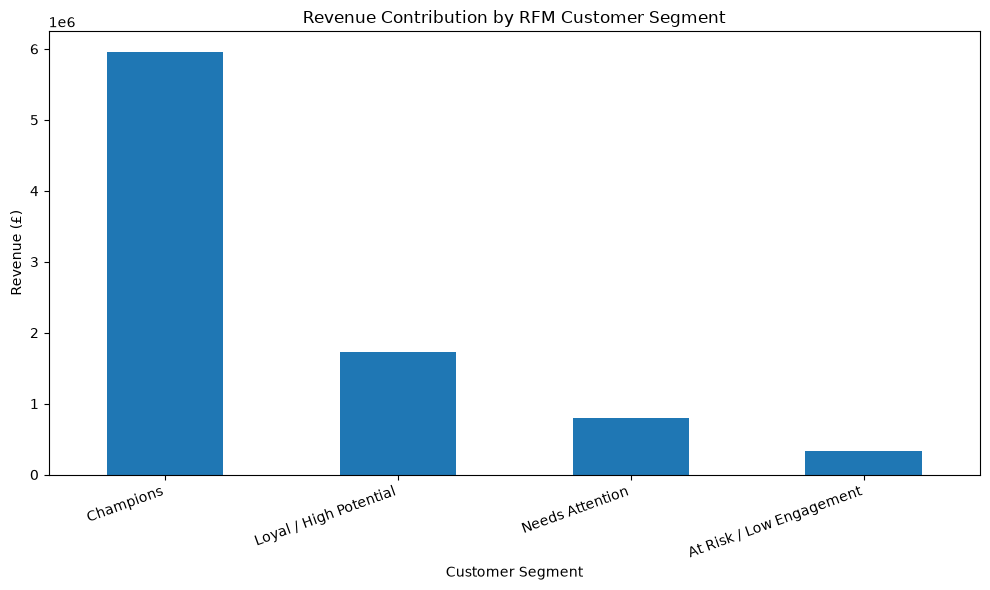

In [133]:
rfm_revenue = (
    customer_metrics.groupby("RFMSegment")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

rfm_revenue.plot(kind="bar")

plt.title("Revenue Contribution by RFM Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

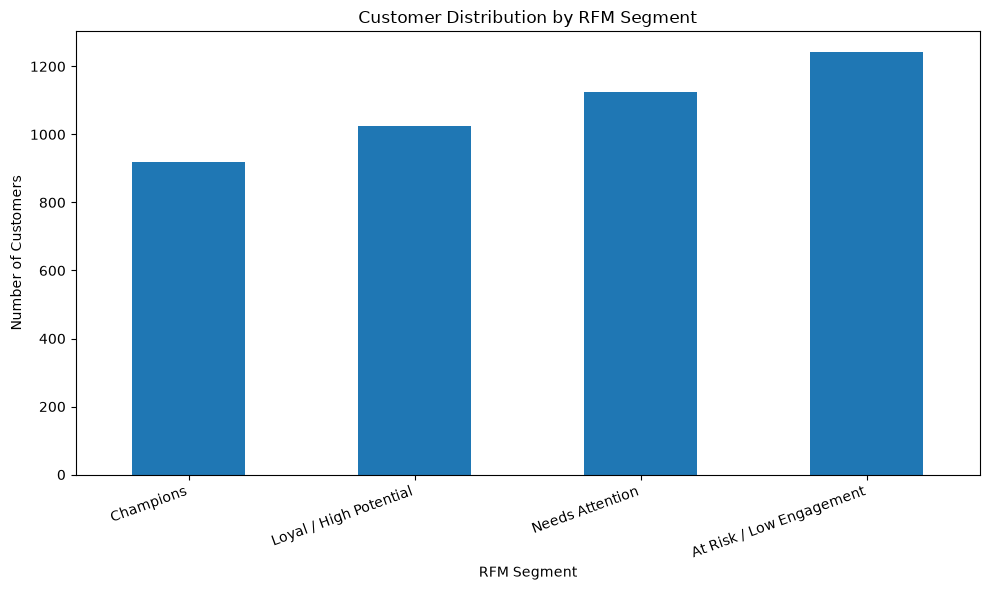

In [134]:
rfm_customer_count = (
    customer_metrics["RFMSegment"]
    .value_counts()
    .reindex([
        "Champions",
        "Loyal / High Potential",
        "Needs Attention",
        "At Risk / Low Engagement"
    ])
)

plt.figure(figsize=(10, 6))

rfm_customer_count.plot(kind="bar")

plt.title("Customer Distribution by RFM Segment")
plt.xlabel("RFM Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

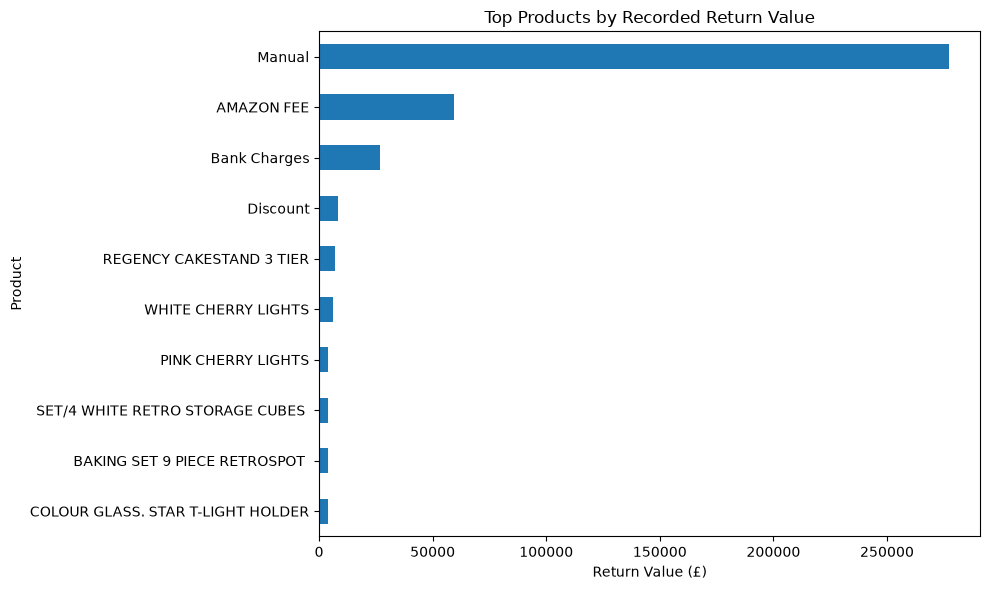

In [135]:
product_return_value = (
    returns_df.groupby("Description")["SalesValue"]
    .sum()
    .abs()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

product_return_value.sort_values().plot(kind="barh")

plt.title("Top Products by Recorded Return Value")
plt.xlabel("Return Value (£)")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

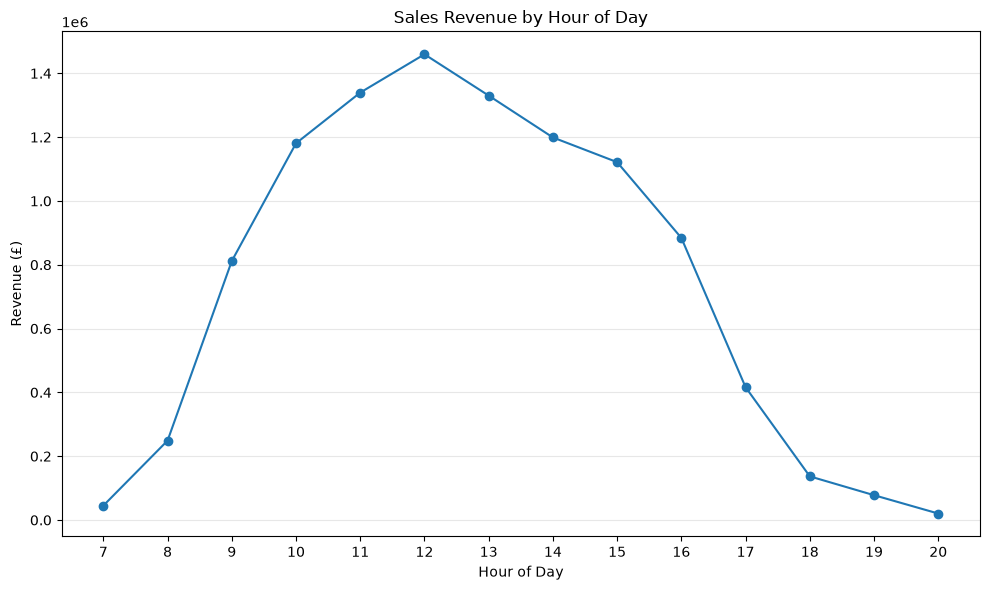

In [136]:
hourly_sales = (
    paid_sales_df.groupby(paid_sales_df["InvoiceDate"].dt.hour)["SalesValue"]
    .sum()
    .sort_index()
)

plt.figure(figsize=(10, 6))

hourly_sales.plot(kind="line", marker="o")

plt.title("Sales Revenue by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Revenue (£)")
plt.xticks(hourly_sales.index)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

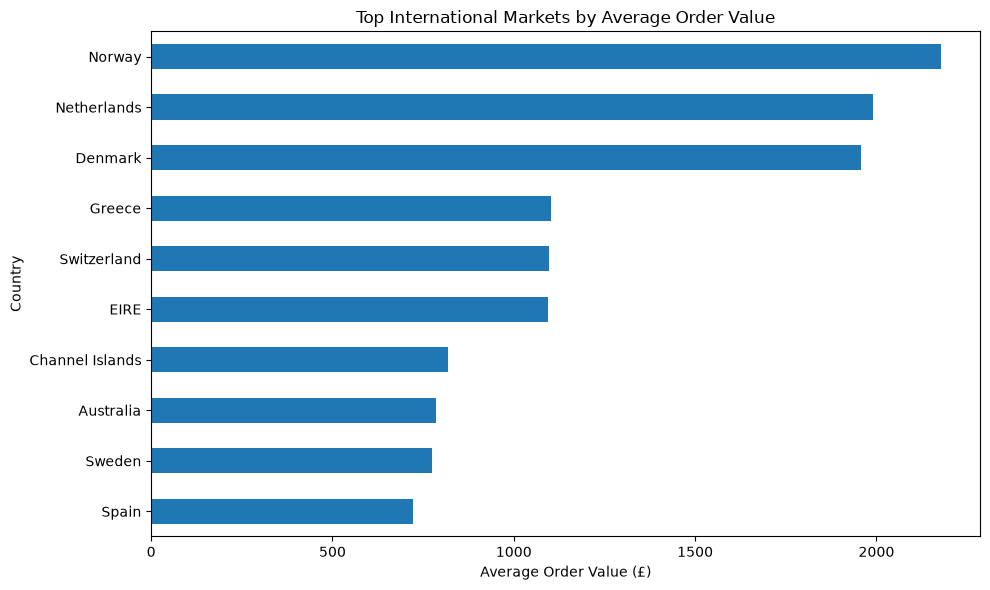

In [137]:
international_aov = (
    country_analysis[
        (country_analysis.index != "United Kingdom") &
        (country_analysis["Orders"] >= 10)
    ]
    .sort_values("AvgOrderValue", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

international_aov["AvgOrderValue"].sort_values().plot(
    kind="barh"
)

plt.title("Top International Markets by Average Order Value")
plt.xlabel("Average Order Value (£)")
plt.ylabel("Country")
plt.tight_layout()
plt.show()